# ₿ BTCUSDT Next-Hour 95% Forecast

AlphaI × Polaris Assignment

This notebook demonstrates:
- fetching BTCUSDT 1-hour candles from Binance
- predicting next-hour 95% price range
- evaluating model via no-peeking backtest

## 1. Setup — Clone repository

In [2]:
!git clone https://github.com/nextgendev2029/btc-forecast-alphai.git
%cd btc-forecast-alphai

Cloning into 'btc-forecast-alphai'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 20 (delta 0), reused 20 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 46.74 KiB | 1.02 MiB/s, done.
/content/btc-forecast-alphai


## 2. Install dependencies

In [3]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 66.1 MB/s eta 0:00:00


## 3. Load BTCUSDT hourly data

In [8]:
from src.data import load_btc_prices

prices = load_btc_prices(limit=1500)

print("Total bars:", len(prices))
print("First timestamp:", prices.index[0])
print("Last timestamp:", prices.index[-1])
print("Latest close:", prices.iloc[-1])

prices.tail()

Total bars: 1500
First timestamp: 2026-02-28 22:59:59.999000+00:00
Last timestamp: 2026-05-02 09:59:59.999000+00:00
Latest close: 78341.78


,close
close_time,
2026-05-02 05:59:59.999000+00:00,78174.00
2026-05-02 06:59:59.999000+00:00,78327.80
2026-05-02 07:59:59.999000+00:00,78220.00
2026-05-02 08:59:59.999000+00:00,78315.37
2026-05-02 09:59:59.999000+00:00,78341.78


## 4. Predict next-hour price range

In [9]:
from src.model import predict_next_range

low, high = predict_next_range(
    prices.tail(500),
    n_sims=5000,
    vol_window=80,
    drift_window=200,
    tail_df=4,
    range_scale=1.05,
    seed=42,
)

print(f"Current BTC price: ${prices.iloc[-1]:,.2f}")
print(f"Predicted 95% range: ${low:,.2f} — ${high:,.2f}")
print(f"Range width: ${high - low:,.2f}")

Current BTC price: $78,341.78
Predicted 95% range: $77,770.30 — $78,887.04
Range width: $1,116.74


## 5. Backtest performance (720 bars)

In [6]:
import pandas as pd

df = pd.read_json("outputs/backtest_results.jsonl", lines=True)

print("Predictions:", len(df))
print("Coverage 95%:", df["covered_95"].mean())
print("Average width:", df["width_95"].mean())
print("Mean Winkler:", df["winkler_95"].mean())

Predictions: 720
Coverage 95%: 0.9486111111111111
Average width: 1195.4106907133973
Mean Winkler: 1774.4318356228378


## 6. Visualization

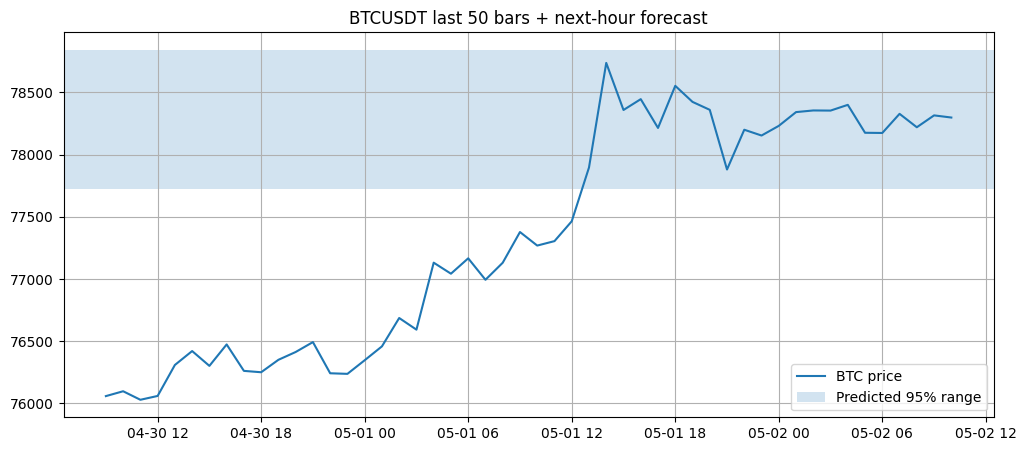

In [7]:
import matplotlib.pyplot as plt

recent = prices.tail(50)

plt.figure(figsize=(12, 5))
plt.plot(recent.index, recent.values, label="BTC price")

plt.axhspan(low, high, alpha=0.2, label="Predicted 95% range")

plt.title("BTCUSDT last 50 bars + next-hour forecast")
plt.legend()
plt.grid()
plt.show()